In [1]:
using JLD2
using Plots


[ Info: Precompiling JLD2 [033835bb-8acc-5ee8-8aae-3f567f8a3819] 
[ Info: Precompiling Plots [91a5bcdd-55d7-5caf-9e0b-520d859cae80] 
[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7] 
[ Info: Precompiling FileIOExt [f5f51d8f-5827-5d2e-939b-192fcd6ec70c] 
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a] 


In [2]:
using JLD2

# The directory where MPO_get_data.jl saves the files (current directory)
data_dir = @__DIR__ 

# Dictionary to store the loaded data: all_data[sigma_string] = loaded_data_dict
all_data = Dict{String, Any}() 

# Define the sigma strings that correspond to the command line arguments you ran
sigma_strings = ["0.0", "1e-6", "1e-5", "0.002"] 

for sig_str in sigma_strings
    file_name = "mpo_scaling_data_sigma_$(sig_str).jld2" 
    file_path = joinpath(data_dir, "data", file_name) 
    
    if isfile(file_path) 
        try
            # JLD2 load function reads the file and returns a dictionary of its contents
            data = load(file_path)
            all_data[sig_str] = data 
            println("Successfully loaded data for: σ = $sig_str")
        catch e
            println("ERROR loading file: $file_name -> $e")
        end
    else
        println("File not found: $file_name") 
    end
end

Successfully loaded data for: σ = 0.0
Successfully loaded data for: σ = 1e-6
Successfully loaded data for: σ = 1e-5
Successfully loaded data for: σ = 0.002


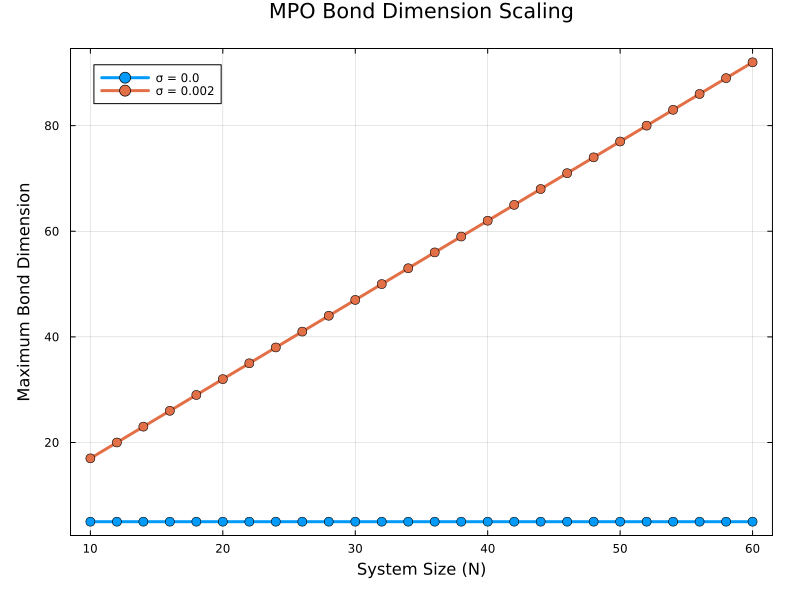

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\mpo_scaling.png"

In [3]:
using Plots

plot_sigmas = ["0.0", "0.002"] 

# Define the N range you wish to plot
N_min = 10
N_max = 60

# Initialise the plot
p = plot(
    title="MPO Bond Dimension Scaling",
    xlabel="System Size (N)",
    ylabel="Maximum Bond Dimension",
    legend=:topleft,
    grid=true,
    framestyle=:box,
    size=(800, 600),
    margins = 5Plots.mm
)

for sig_str in plot_sigmas
    if haskey(all_data, sig_str)
        data = all_data[sig_str]
        
        mpo_bd_avg = data["mpo_bd_avg"]
        mpo_bd_err = data["mpo_bd_err"]
        N_range = data["N_range"]
        
        if sig_str == "0.0"
            mpo_bd_err = nothing
        end

        # Find the indices where N_range falls within the chosen limits
        valid_indices = findall(n -> N_min <= n <= N_max, N_range)
        
        # Extract the subset of data using these indices
        filtered_N = N_range[valid_indices]
        filtered_avg = mpo_bd_avg[valid_indices]
        
        # Safely filter the error array if it is not set to nothing
        filtered_err = isnothing(mpo_bd_err) ? nothing : mpo_bd_err[valid_indices]

        plot!(
            p, 
            filtered_N, 
            filtered_avg,
            # yerror=filtered_err,
            label="σ = $sig_str",
            marker=:circle,
            markersize=5,
            linewidth=3,
            markerstrokewidth=0.5
        )
    else
        println("Warning: Data for σ = $sig_str not found in all_data. Skipping...")
    end
end

display(p)

savefig(p, joinpath(@__DIR__, "images", "mpo_scaling.png"))